In [95]:
# Import all these necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Import tensorflow then keras and then Sequential model and for that model the Dense and the Input function
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [96]:
df = pd.read_csv('Churn_Modelling.csv') # A kaggle dataset for customer churn prediction

In [97]:
df.head() # Skim the head

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [98]:
df.shape # Check the dimensions to know how big of data we are dealing with

(10000, 14)

In [99]:
df.info() # Check for any null values and anamolies

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [100]:
df.duplicated().sum() # Check for duplicates

np.int64(0)

In [101]:
# Check whether the output column is imbalanced or not
df['Exited'].value_counts()# <-- Our O/P : Imbalanced but we leave it as it is because this is just a demonstration of the ANN (can be improved later)

Exited
0    7963
1    2037
Name: count, dtype: int64

In [102]:
df['Gender'].value_counts() # <-- Check the same for the gender column

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [103]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']) #<-- Dropping these columns for simplyifing the task for now , assumming surname is not important

In [104]:
df.head() #Quick check

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [105]:
df = pd.get_dummies(df,columns=['Gender','Geography'],drop_first=True)
# Basically simply converting classess of each into their own column

In [106]:
df.head() # Again check

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [107]:
# It is advised that we scale the values before feeding the model so that the model converges faster

In [108]:
# First split the dataset
X,y = df.drop(columns=['Exited']),df['Exited']

In [109]:
# Then split into training and testing set with appropriate proportions
X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [110]:
X_train.shape,y_train.shape # <-- Check the dims of Training set 

((8000, 11), (8000,))

In [111]:
X_test.shape,y_test.shape # <-- Check the dims of Testing set 

((2000, 11), (2000,))

In [112]:
# Now scale these value using StandardScaler

In [113]:
scaler = StandardScaler()

# Always fit on training set beforehand and then only apply transform to both especially test set to avoid data leaks
scaler.fit(X_train)

X_train_scalled = scaler.transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [ ]:
X_train_scalled[:3] # Skim the top3 values

array([[ 0.35649971, -0.6557859 ,  0.34567966, -1.21847056,  0.80843615,
         0.64920267,  0.97481699,  1.36766974,  0.91324755, -0.57946723,
        -0.57638802],
       [-0.20389777,  0.29493847, -0.3483691 ,  0.69683765,  0.80843615,
         0.64920267,  0.97481699,  1.6612541 ,  0.91324755,  1.72572313,
        -0.57638802],
       [-0.96147213, -1.41636539, -0.69539349,  0.61862909, -0.91668767,
         0.64920267, -1.02583358, -0.25280688,  0.91324755, -0.57946723,
         1.73494238]])

In [ ]:
X_test_scalled[:3] # Skim the top3 values

array([[-0.57749609, -0.6557859 , -0.69539349,  0.32993735,  0.80843615,
        -1.54035103, -1.02583358, -1.01960511,  0.91324755,  1.72572313,
        -0.57638802],
       [-0.29729735,  0.3900109 , -1.38944225, -1.21847056,  0.80843615,
         0.64920267,  0.97481699,  0.79888291,  0.91324755, -0.57946723,
        -0.57638802],
       [-0.52560743,  0.48508334, -0.3483691 , -1.21847056,  0.80843615,
         0.64920267, -1.02583358, -0.72797953, -1.09499335, -0.57946723,
         1.73494238]])

In [116]:
# Import all the libraries as stated at the start

In [ ]:
model = Sequential()

model.add(Input(shape=(11,)))  # <--- Pass the no of columns in X
# This is the new version of tensorflow where we explicilty have a function to specify Input shape
# In older version it was mergerd with the Dense function which is now deprecated

model.add(Dense(3,activation='sigmoid'))  # <-- Hidden Layer
# Dense network functions where the parameters are : no of nodes and activation function
model.add(Dense(1,activation='sigmoid')) # <-- Output Layer

In [ ]:
model.summary() # A function which summarizes our model and the parameters in each layer passed

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Basically we set here the loss function and the optimizer that enhances the speed
model.compile(loss='binary_crossentropy',optimizer='Adam') 

In [ ]:
# This is the fitting stage where pass the training sets , epochs and validation split 
# We also store it into a variable history which can be used to visualize the training process for evaluation.
history = model.fit(X_train_scalled,y_train,epochs=10)

Epoch 1/10


250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.9159
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7095
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6056
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5500
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5176
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4983
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4856
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4759
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4671
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4591


In [ ]:
model.layers[0].get_weights() # L0 wieghts and bias

[array([[-0.25211963,  0.11184414, -0.42977044],
        [ 1.121265  , -1.2947588 ,  0.6626548 ],
        [ 0.11966874,  0.02569658, -0.12886585],
        [ 0.61732733, -0.3922472 ,  0.15144671],
        [ 0.3163649 ,  0.06397445, -0.88848644],
        [-0.09861614,  0.14106542, -0.10060564],
        [-0.81900924,  0.84904706, -0.38816565],
        [ 0.40108642,  0.05384915,  0.23014776],
        [ 0.01874036,  0.68987966, -0.4378766 ],
        [ 0.88742584, -0.92971706,  0.11875411],
        [-0.2757954 , -0.14099391, -0.15239577]], dtype=float32),
 array([-0.505633  ,  0.6271638 , -0.59217745], dtype=float32)]

In [ ]:
model.layers[1].get_weights() # L1 wieghts and bias

[array([[ 0.2766273 ],
        [-1.0208025 ],
        [ 0.27806225]], dtype=float32),
 array([-0.9680607], dtype=float32)]

In [ ]:
y_log = model.predict(X_test_scalled) # These are just probablilities so we store it temporarily now.

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [ ]:
y_pred = np.where(y_log>0.5,1,0) # We use the where function to make a simple step function from the given probabilities to binary O/P.

In [125]:
# Calculate Accuracy
accuracy_score(y_test,y_pred)

0.8035

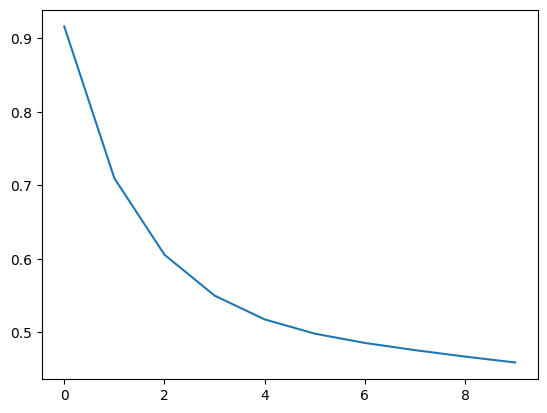

In [ ]:
plt.plot(history.history['loss']) # <-- Plots the loss over epochs

In [127]:
# Tweaks for better result:
'''
        Increase no of epochs
        Increase the no of Nodes in Hidden Layer
        Increase No of Layers
        Use ReLu as Activation Function

    '''
# Also can use validation set while fitting


# plt.plot(history.history['val_loss'])
# plt.plot(history.history['accuracy'])

'\n        Increase no of epochs\n        Increase the no of Nodes in Hidden Layer\n        Increase No of Layers\n        Use ReLu as Activation Function\n\n    '